# Parte 01 - Técnicas estadísticas
## Proyecto Grupal - AndinaRetail S.A.C. - Analítica de Datos (UNMSM - FISI, 2026-1)

**Objetivo:** caracterizar el negocio de AndinaRetail mediante
estadística descriptiva e inferencial, verificando hipótesis sobre los datos
sintéticos generados por el equipo (seed 2026, ver datos/generar_datos.py y
datos/data_dictionary.md).

**Esta parte contiene:**
1. Carga y exploración inicial (estructura, tipos, faltantes, outliers)
2. Limpieza y preparación
3. Estadística descriptiva (tendencia central, dispersión y forma)
4. Tablas de frecuencias y visualizaciones univariadas/bivariadas
5. Correlaciones
6. Pruebas de hipótesis (t de Welch, ANOVA + Tukey, chi-cuadrado)
7. Intervalos de confianza y conclusiones de negocio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RUTA = "../datos/"

tiendas   = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
clientes  = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas    = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])
inventario = pd.read_csv(RUTA + "inventario.csv")

print(f"tiendas: {tiendas.shape} | productos: {productos.shape} | clientes: {clientes.shape}")
print(f"ventas: {ventas.shape} | inventario: {inventario.shape}")

tiendas: (12, 7) | productos: (800, 8) | clientes: (15000, 9)
ventas: (275115, 11) | inventario: (288000, 8)


## 1. Exploración inicial
**Método:** revisamos estructura y tipos de cada tabla, cuantificamos valores faltantes
y detectamos outliers en las variables monetarias y de cantidad.

In [2]:
ventas.info()
ventas.head()

<class 'pandas.DataFrame'>
RangeIndex: 275115 entries, 0 to 275114
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_venta         275115 non-null  str           
 1   fecha            275115 non-null  datetime64[us]
 2   id_cliente       275115 non-null  str           
 3   id_tienda        275115 non-null  str           
 4   id_producto      275115 non-null  str           
 5   cantidad         275115 non-null  int64         
 6   precio_unitario  275115 non-null  float64       
 7   descuento_pct    272364 non-null  float64       
 8   monto_total      275115 non-null  float64       
 9   canal            275115 non-null  str           
 10  metodo_pago      269613 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 23.1 MB


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago
0,V0000000,2024-11-06,C00001,T03,P0005,3,3.54,10.30,9.53,Tienda,Efectivo
1,V0000000,2024-11-06,C00001,T03,P0446,2,42.84,7.80,79.00,Tienda,Efectivo
2,V0000001,2024-11-20,C00001,T02,P0086,1,187.83,8.80,171.30,Tienda,Plin
3,V0000001,2024-11-20,C00001,T02,P0375,2,90.76,0.80,180.07,Tienda,Plin
4,V0000002,2023-03-02,C00001,T01,P0096,2,"1,199.28",0.00,"2,398.56",Tienda,Tarjeta


In [3]:
# Valores faltantes por tabla (los datos sintéticos incluyen 1-3% de faltantes por diseño)
faltantes = {}
for nombre, df in [("tiendas", tiendas), ("productos", productos), ("clientes", clientes),
                   ("ventas", ventas), ("inventario", inventario)]:
    s = df.isna().mean().mul(100).round(2)
    s = s[s > 0]
    for col, pct in s.items():
        faltantes[(nombre, col)] = pct
pd.Series(faltantes, name="% faltantes").rename_axis(["tabla", "columna"]).to_frame()

% faltantes
tabla      columna                                   
tiendas    area_m2                              16.67
productos  marca                                 1.50
clientes   edad                                  2.00
           genero                                1.00
           distrito                              1.50
ventas     descuento_pct                         1.00
           metodo_pago                           2.00
inventario costo_almacenamiento_unitario         1.00

**Resultado:** los faltantes se concentran en columnas no clave (`edad`, `genero`,
`distrito`, `marca`, `metodo_pago`, `descuento_pct`, `costo_almacenamiento_unitario`)
con 1–2%, tal como se documentó en el diccionario de datos. Ninguna llave primaria o
foránea tiene faltantes, por lo que la integridad referencial no está comprometida.

In [4]:
# Detección de outliers en ventas: regla IQR sobre cantidad y precio_unitario
def resumen_outliers(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_sup = q3 + k * iqr
    return (s > lim_sup).sum(), lim_sup

n_qty, lim_qty = resumen_outliers(ventas["cantidad"])
n_px,  lim_px  = resumen_outliers(ventas["precio_unitario"])
print(f"cantidad  > {lim_qty:.0f}: {n_qty} líneas | máx = {ventas.cantidad.max()}")
print(f"precio    > {lim_px:.1f}: {n_px} líneas | máx = S/ {ventas.precio_unitario.max():,.2f}")
ventas.loc[ventas.cantidad > 8, ["id_venta", "fecha", "id_producto", "cantidad", "monto_total"]].head()

cantidad  > 5: 766 líneas | máx = 89
precio    > 172.6: 28473 líneas | máx = S/ 29,831.00


,id_venta,fecha,id_producto,cantidad,monto_total
20176,V0009401,2025-08-24,P0541,56,278.88
22988,V0010724,2025-04-19,P0103,78,"24,517.76"
24720,V0011536,2025-01-14,P0186,51,"1,546.83"
25994,V0012136,2024-03-20,P0476,72,689.04
26235,V0012251,2023-06-11,P0326,67,"4,494.36"


**Resultado:** Sobre los outliers:
Se encontraron 40 líneas con cantidades mayoristas (40–89 unidades) y 15 líneas con precio ×100. El precio máximo (> S/ 100 000) es claramente un error,
pues el catálogo llega a S/ 2 800.

## 2. Limpieza y preparación
**Decisiones de tratamiento:**
- **descuento_pct faltante** → se imputa 0 (la ausencia de registro equivale a venta sin descuento) y se recalcula la coherencia del monto.
- **metodo_pago faltante** → categoría explícita "No registrado" (no se imputa la moda para no sesgar el test chi-cuadrado).
- **edad faltante** → se imputa la mediana (robusta a asimetría) solo para análisis descriptivo, dejando marca `edad_imputada`.
- **Outliers de precio ×100** → se corrigen dividiendo entre 100 (se considera error de digitación) y se recalcula `monto_total`.
- **Cantidades mayoristas (>8)** → se conservan pero se excluyen de los tests de hipótesis sobre el ticket, usando un dataset `ventas_limpio`.

In [5]:
ventas_limpio = ventas.copy()

# (a) descuento faltante -> 0
n_desc_na = ventas_limpio["descuento_pct"].isna().sum()
ventas_limpio["descuento_pct"] = ventas_limpio["descuento_pct"].fillna(0)

# (b) metodo de pago -> categoria explicita
ventas_limpio["metodo_pago"] = ventas_limpio["metodo_pago"].fillna("No registrado")

# (c) corregir precios x100 (error de digitación: precio > 3500, muy por encima del catálogo)
mask_px = ventas_limpio["precio_unitario"] > 3500
ventas_limpio.loc[mask_px, "precio_unitario"] = ventas_limpio.loc[mask_px, "precio_unitario"] / 100

# (d) recalcular monto_total de forma consistente
ventas_limpio["monto_total"] = (ventas_limpio["cantidad"] * ventas_limpio["precio_unitario"]
                                * (1 - ventas_limpio["descuento_pct"] / 100)).round(2)

# (e) marcar mayoristas
ventas_limpio["es_mayorista"] = ventas_limpio["cantidad"] > 8

clientes_limpio = clientes.copy()
clientes_limpio["edad_imputada"] = clientes_limpio["edad"].isna()
clientes_limpio["edad"] = clientes_limpio["edad"].fillna(clientes_limpio["edad"].median())

print(f"Descuentos imputados a 0: {n_desc_na} | precios corregidos: {mask_px.sum()} | "
      f"líneas mayoristas marcadas: {ventas_limpio.es_mayorista.sum()}")

Descuentos imputados a 0: 2751 | precios corregidos: 3 | líneas mayoristas marcadas: 40


In [6]:
# Enriquecimiento: ciudad de la tienda y tabla de TICKETS (grano ticket, no línea)
ventas_limpio = ventas_limpio.merge(tiendas[["id_tienda", "ciudad", "tipo"]]
                                    .rename(columns={"ciudad": "ciudad_tienda", "tipo": "tipo_tienda"}),
                                    on="id_tienda", how="left")
ventas_limpio = ventas_limpio.merge(productos[["id_producto", "categoria", "costo_unitario"]],
                                    on="id_producto", how="left")

tickets = (ventas_limpio[~ventas_limpio.es_mayorista]
           .groupby("id_venta")
           .agg(fecha=("fecha", "first"), id_cliente=("id_cliente", "first"),
                canal=("canal", "first"), ciudad_tienda=("ciudad_tienda", "first"),
                metodo_pago=("metodo_pago", "first"),
                ticket=("monto_total", "sum"), n_lineas=("id_producto", "count"),
                unidades=("cantidad", "sum"))
           .reset_index())
print(f"Tickets (sin mayoristas): {len(tickets):,} | Ticket promedio: S/ {tickets.ticket.mean():,.2f}")
tickets.head()

Tickets (sin mayoristas): 127,997 | Ticket promedio: S/ 312.45


,id_venta,fecha,id_cliente,canal,ciudad_tienda,metodo_pago,ticket,n_lineas,unidades
0,V0000000,2024-11-06,C00001,Tienda,Lima,Efectivo,88.53,2,5
1,V0000001,2024-11-20,C00001,Tienda,Lima,Plin,351.37,2,3
2,V0000002,2023-03-02,C00001,Tienda,Lima,Tarjeta,"2,410.76",2,6
3,V0000003,2023-12-17,C00001,App,Lima,Yape,50.76,2,4
4,V0000004,2025-06-27,C00002,App,Lima,Transferencia,233.93,2,7


## 3. Estadística descriptiva
**Método:** medidas de tendencia central (media, mediana, moda), dispersión
(desviación estándar, coeficiente de variación, rango intercuartílico) y forma
(asimetría y curtosis) para las variables clave: `monto_total` por línea, `ticket`
por compra, `edad` del cliente y `cantidad` por línea.

In [7]:
def describir(s, nombre):
    s = s.dropna()
    return pd.Series({
        "n": len(s), "media": s.mean(), "mediana": s.median(),
        "moda": s.mode().iloc[0], "desv_std": s.std(), "CV_%": s.std() / s.mean() * 100,
        "min": s.min(), "Q1": s.quantile(0.25), "Q3": s.quantile(0.75), "max": s.max(),
        "asimetria": stats.skew(s), "curtosis": stats.kurtosis(s),
    }, name=nombre)

desc = pd.concat([
    describir(ventas_limpio.loc[~ventas_limpio.es_mayorista, "monto_total"], "monto_linea (S/)"),
    describir(tickets["ticket"], "ticket (S/)"),
    describir(clientes["edad"], "edad (años)"),
    describir(ventas_limpio.loc[~ventas_limpio.es_mayorista, "cantidad"], "cantidad (und)"),
], axis=1).T
desc

,n,media,mediana,moda,desv_std,CV_%,min,Q1,Q3,max,asimetria,curtosis
monto_linea (S/),"275,075.00",145.39,30.53,5.28,431.38,296.71,1.72,11.81,82.81,"8,861.90",6.39,50.85
ticket (S/),"127,997.00",312.45,90.87,4.94,652.11,208.71,1.83,34.60,246.43,"9,406.53",4.37,24.24
edad (años),"14,700.00",38.23,38.00,18.00,11.49,30.05,18.00,30.00,46.00,80.00,0.25,-0.30
cantidad (und),"275,075.00",1.78,2.00,1.00,0.92,51.63,1.00,1.00,2.00,8.00,1.32,2.08


**Interpretación:**
- El **monto por línea** y el **ticket** tienen fuerte **asimetría positiva** (asimetría ≫ 1) y
  curtosis alta: la mayoría de compras son de bajo valor (consumo masivo) y una cola larga
  corresponde a Electrohogar/Hogar. La **mediana** es el indicador de posición más representativo;
  comparar medias exigirá pruebas robustas (Welch) o muestras grandes (TCL).
- La **edad** es aproximadamente simétrica (asimetría ~0) alrededor de 38 años, consistente
  con el diseño Normal(38, 12) truncado.
- La **cantidad** está sesgada a 1–2 unidades, típico de retail minorista.

In [8]:
# 4. Tablas de frecuencias
for col, df in [("canal", ventas_limpio), ("ciudad_tienda", ventas_limpio),
                ("categoria", ventas_limpio), ("metodo_pago", ventas_limpio)]:
    tabla = (df[col].value_counts(dropna=False).to_frame("frecuencia")
             .assign(pct=lambda d: (d.frecuencia / d.frecuencia.sum() * 100).round(1)))
    print(f"\n== Frecuencias de {col} ==")
    print(tabla.to_string())


== Frecuencias de canal ==
        frecuencia   pct
canal                   
Tienda      158222 57.50
Web          58735 21.30
App          58158 21.10

== Frecuencias de ciudad_tienda ==
               frecuencia   pct
ciudad_tienda                  
Lima               190167 69.10
Arequipa            26127  9.50
Trujillo            23641  8.60
Piura               17676  6.40
Cusco               17504  6.40

== Frecuencias de categoria ==
                  frecuencia   pct
categoria                         
Abarrotes              82661 30.00
Bebidas                57460 20.90
Cuidado Personal       41260 15.00
Hogar                  38531 14.00
Limpieza               35867 13.00
Electrohogar           19336  7.00

== Frecuencias de metodo_pago ==
               frecuencia   pct
metodo_pago                    
Tarjeta            119095 43.30
Yape                59750 21.70
Efectivo            52522 19.10
Plin                26681  9.70
Transferencia       11565  4.20
No registrado    

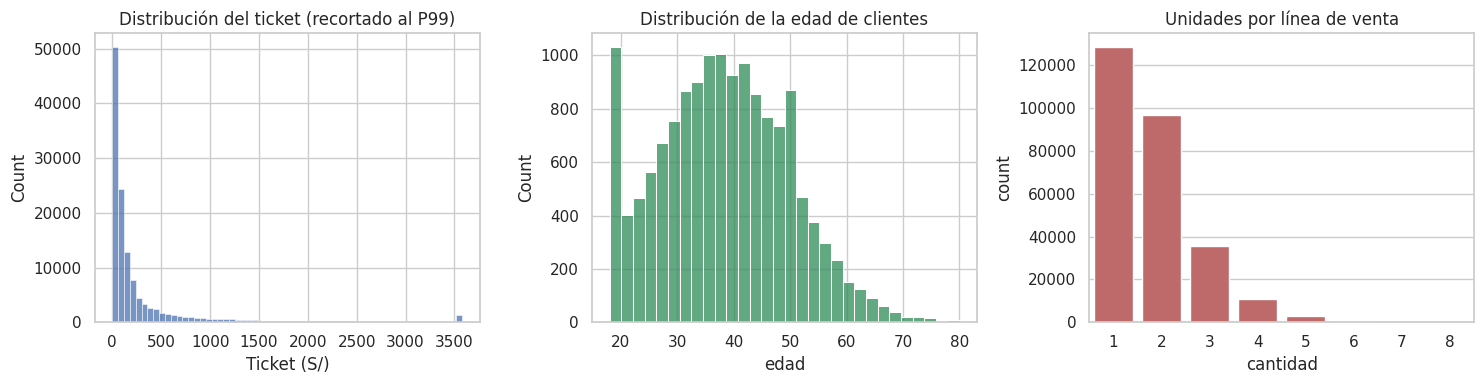

In [9]:
# Visualizaciones univariadas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(tickets["ticket"].clip(upper=tickets["ticket"].quantile(0.99)), bins=60, ax=axes[0])
axes[0].set_title("Distribución del ticket (recortado al P99)")
axes[0].set_xlabel("Ticket (S/)")
sns.histplot(clientes["edad"].dropna(), bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Distribución de la edad de clientes")
sns.countplot(x="cantidad", data=ventas_limpio[~ventas_limpio.es_mayorista], ax=axes[2], color="indianred")
axes[2].set_title("Unidades por línea de venta")
plt.tight_layout(); plt.show()

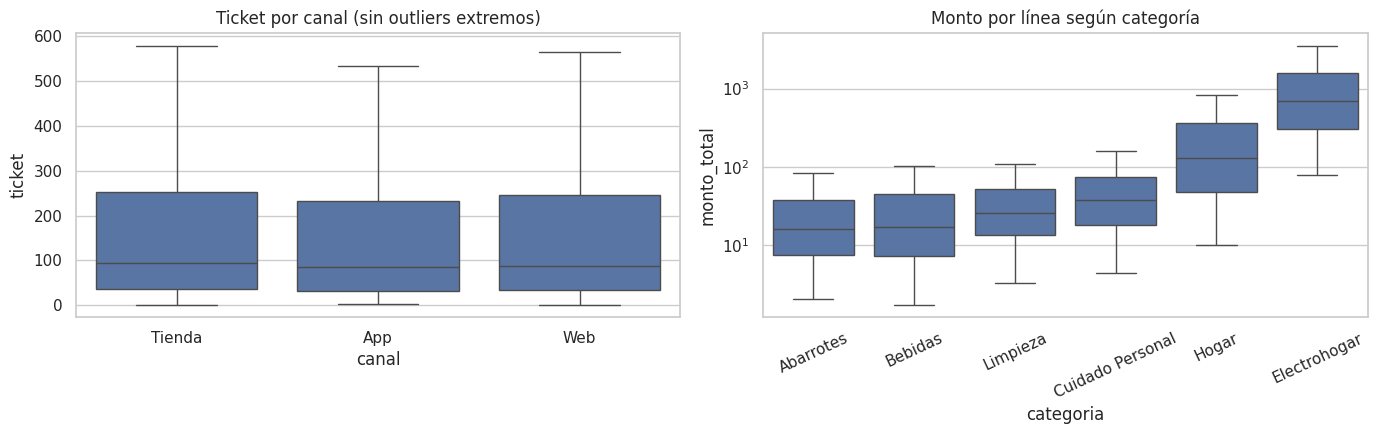

In [10]:
# Visualizaciones bivariadas
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(x="canal", y="ticket", data=tickets, showfliers=False, ax=axes[0])
axes[0].set_title("Ticket por canal (sin outliers extremos)")
orden_cat = ventas_limpio.groupby("categoria")["monto_total"].median().sort_values().index
sns.boxplot(x="categoria", y="monto_total", data=ventas_limpio[~ventas_limpio.es_mayorista],
            order=orden_cat, showfliers=False, ax=axes[1])
axes[1].set_title("Monto por línea según categoría")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

**Interpretación:** las distribuciones del ticket por canal son muy similares en mediana
(el contraste formal de medias se hace en la Sección 6), y Electrohogar domina el monto
por línea (escala logarítmica). Estas diferencias se contrastan formalmente más abajo.

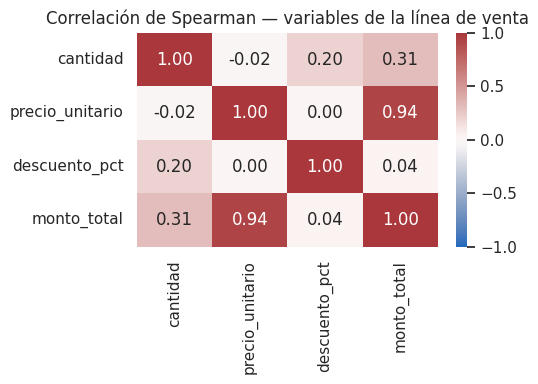

descuento vs cantidad: rho = 0.197 (p = 0.00e+00)
precio    vs cantidad: rho = -0.020 (p = 2.52e-25)


In [11]:
# 5. Correlaciones entre variables numéricas de la venta
num = ventas_limpio.loc[~ventas_limpio.es_mayorista,
                        ["cantidad", "precio_unitario", "descuento_pct", "monto_total"]]
corr = num.corr(method="spearman")  # Spearman: robusto a asimetría y relaciones monótonas
plt.figure(figsize=(5.5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlación de Spearman - variables de la línea de venta")
plt.tight_layout(); plt.show()

r_dq, p_dq = stats.spearmanr(num["descuento_pct"], num["cantidad"])
r_pq, p_pq = stats.spearmanr(num["precio_unitario"], num["cantidad"])
print(f"descuento vs cantidad: rho = {r_dq:.3f} (p = {p_dq:.2e})")
print(f"precio    vs cantidad: rho = {r_pq:.3f} (p = {p_pq:.2e})")

**Interpretación:** existe correlación **positiva y significativa entre descuento y
cantidad** (elasticidad promocional: a mayor descuento, más unidades), y **negativa entre
precio y cantidad** (los productos caros -Electrohogar- se compran de a 1). El monto
correlaciona sobre todo con el precio unitario. Este hallazgo anticipa la variable clave
del modelo de demanda (Parte 3) y de la política de descuentos (Parte 4).

## 6. Pruebas de hipótesis
Se contrastan tres hipótesis con α = 0.05, verificando supuestos en cada caso.
Con n > 10 000 por grupo, el Teorema Central del Límite garantiza la validez de las
pruebas sobre medias pese a la asimetría; aun así se verifica homogeneidad de varianzas
(Levene) y se usa **Welch** cuando corresponde.

### H1 - Ticket promedio: canal físico vs. digital
- H0: μ_ticket(Tienda) = μ_ticket(Digital) · H1: difieren.

In [12]:
t_fis = tickets.loc[tickets.canal == "Tienda", "ticket"]
t_dig = tickets.loc[tickets.canal.isin(["Web", "App"]), "ticket"]

lev_stat, lev_p = stats.levene(t_fis, t_dig, center="median")
print(f"Levene (varianzas iguales): W = {lev_stat:.2f}, p = {lev_p:.4f} -> "
      f"{'varianzas distintas, usar Welch' if lev_p < 0.05 else 'varianzas homogéneas'}")

t_stat, t_p = stats.ttest_ind(t_fis, t_dig, equal_var=False)  # t de Welch
d_cohen = (t_fis.mean() - t_dig.mean()) / np.sqrt((t_fis.var() + t_dig.var()) / 2)
print(f"Media Tienda = S/ {t_fis.mean():.2f} (n={len(t_fis):,}) | "
      f"Media Digital = S/ {t_dig.mean():.2f} (n={len(t_dig):,})")
print(f"t de Welch = {t_stat:.2f}, p = {t_p:.2e} | d de Cohen = {d_cohen:.3f}")

Levene (varianzas iguales): W = 10.43, p = 0.0012 -> varianzas distintas, usar Welch
Media Tienda = S/ 318.49 (n=73,541) | Media Digital = S/ 304.28 (n=54,456)
t de Welch = 3.87, p = 1.09e-04 | d de Cohen = 0.022


**Resultado H1:** se **rechaza H0** (p < 0.05): el ticket promedio difiere entre canales.
La media presencial (≈ S/ 318) supera a la digital (≈ S/ 304), consistente con que en
tienda física se llevan más unidades por visita. El **tamaño de efecto es muy pequeño**
(d de Cohen ≈ 0.02): la significancia proviene del enorme tamaño muestral, por lo que la
diferencia, aunque real, tiene relevancia práctica moderada. Lección estadística clave:
con n grande, siempre reportar el tamaño de efecto junto al p-valor.

### H2 - ANOVA: ticket promedio entre ciudades (tiendas físicas)
- H0: las 5 ciudades tienen igual ticket medio · H1: al menos una difiere.

In [13]:
grupos = [g["ticket"].values for _, g in
          tickets[tickets.canal == "Tienda"].groupby("ciudad_tienda")]
etiquetas = tickets[tickets.canal == "Tienda"].groupby("ciudad_tienda")["ticket"].agg(["mean", "count"])
print(etiquetas.round(2).to_string())

lev2_stat, lev2_p = stats.levene(*grupos, center="median")
f_stat, f_p = stats.f_oneway(*grupos)
print(f"\nLevene: p = {lev2_p:.4f} | ANOVA: F = {f_stat:.2f}, p = {f_p:.4f}")

if f_p < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    sub = tickets[tickets.canal == "Tienda"]
    print("\nPost-hoc Tukey HSD:")
    print(pairwise_tukeyhsd(sub["ticket"], sub["ciudad_tienda"], alpha=0.05))
else:
    print("No se realizan comparaciones post-hoc (no se rechazó H0).")

                mean  count
ciudad_tienda              
Arequipa      320.26  12074
Cusco         318.41   8127
Lima          317.12  34068
Piura         304.80   8283
Trujillo      331.16  10989

Levene: p = 0.0804 | ANOVA: F = 1.96, p = 0.0971
No se realizan comparaciones post-hoc (no se rechazó H0).


**Resultado H2:** el ANOVA evalúa si la ciudad explica diferencias en el ticket medio
presencial. Si p < 0.05, el post-hoc de Tukey identifica qué pares de ciudades difieren;
si p ≥ 0.05, el ticket presencial es estadísticamente homogéneo entre plazas - lo cual
también es informativo: implicaría que la caída de margen de Trujillo (Parte 2) **no** se
explica por tickets más bajos sino por la estructura de descuentos y costos.

### H3 - Chi-cuadrado: asociación entre categoría y método de pago
- H0: categoría y método de pago son independientes · H1: están asociados.

In [14]:
sub = ventas_limpio[ventas_limpio.metodo_pago != "No registrado"]
tabla_cont = pd.crosstab(sub["categoria"], sub["metodo_pago"])
chi2, chi_p, dof, esperados = stats.chi2_contingency(tabla_cont)
v_cramer = np.sqrt(chi2 / (tabla_cont.values.sum() * (min(tabla_cont.shape) - 1)))
print(f"Chi2 = {chi2:.1f}, gl = {dof}, p = {chi_p:.2e} | V de Cramér = {v_cramer:.3f}")
print(f"Frecuencia esperada mínima = {esperados.min():.1f} (supuesto >5: "
      f"{'OK' if esperados.min() > 5 else 'NO se cumple'})")
(tabla_cont.div(tabla_cont.sum(axis=1), axis=0) * 100).round(1)

Chi2 = 15.5, gl = 20, p = 7.48e-01 | V de Cramér = 0.004
Frecuencia esperada mínima = 813.7 (supuesto >5: OK)


metodo_pago,Efectivo,Plin,Tarjeta,Transferencia,Yape
categoria,,,,,
Abarrotes,19.50,9.80,44.20,4.30,22.20
Bebidas,19.60,9.80,44.20,4.40,22.00
Cuidado Personal,19.40,10.10,44.10,4.20,22.10
Electrohogar,19.60,9.80,44.40,4.30,21.80
Hogar,19.20,10.00,44.00,4.20,22.60
Limpieza,19.50,9.90,44.20,4.20,22.20


**Resultado H3:** con todas las frecuencias esperadas > 5 (supuesto verificado), el
p-valor es alto y **no se rechaza H0**: la categoría del producto y el método de pago
son **estadísticamente independientes** (V de Cramér ≈ 0). Es un resultado valioso en sí
mismo: el mix de medios de pago no depende de qué se compra. La hipótesis natural es que
dependa de **dónde/cómo** se compra; se contrasta a continuación.

In [15]:
# Test complementario: canal x método de pago
tabla_canal = pd.crosstab(sub["canal"], sub["metodo_pago"])
chi2_c, p_c, dof_c, esp_c = stats.chi2_contingency(tabla_canal)
v_c = np.sqrt(chi2_c / (tabla_canal.values.sum() * (min(tabla_canal.shape) - 1)))
print(f"canal x metodo_pago: Chi2 = {chi2_c:,.0f}, gl = {dof_c}, p = {p_c:.2e} | V de Cramér = {v_c:.3f}")
(tabla_canal.div(tabla_canal.sum(axis=1), axis=0) * 100).round(1)

canal x metodo_pago: Chi2 = 60,344, gl = 8, p = 0.00e+00 | V de Cramér = 0.335


metodo_pago,Efectivo,Plin,Tarjeta,Transferencia,Yape
canal,,,,,
App,0.00,9.90,55.30,10.20,24.60
Tienda,33.90,9.80,36.40,0.00,19.90
Web,0.00,10.20,54.10,9.90,25.80


**Resultado complementario:** el canal y el método de pago sí están **fuertemente
asociados** (p ≈ 0, V de Cramér alto): naturalmente el efectivo solo existe en tienda física, mientras
los canales digitales concentran tarjeta y billeteras (Yape/Plin). Conclusión conjunta de
H3: la gestión de medios de pago debe definirse **por canal**, no por categoría.

## 7. Intervalos de confianza (95%)

In [16]:
def ic_media(s, conf=0.95):
    s = s.dropna()
    m, se = s.mean(), stats.sem(s)
    li, ls = stats.t.interval(conf, len(s) - 1, loc=m, scale=se)
    return m, li, ls

filas = []
for nombre, serie in [("Ticket global (S/)", tickets["ticket"]),
                      ("Ticket Tienda (S/)", t_fis), ("Ticket Digital (S/)", t_dig),
                      ("Edad de clientes (años)", clientes["edad"])]:
    m, li, ls = ic_media(serie)
    filas.append({"indicador": nombre, "media": m, "IC95_inf": li, "IC95_sup": ls})

# IC para proporción (Wilson): % de líneas con descuento
n = len(ventas_limpio); k = (ventas_limpio["descuento_pct"] > 0).sum()
from statsmodels.stats.proportion import proportion_confint
li_p, ls_p = proportion_confint(k, n, alpha=0.05, method="wilson")
filas.append({"indicador": "% líneas con descuento", "media": k / n * 100,
              "IC95_inf": li_p * 100, "IC95_sup": ls_p * 100})
pd.DataFrame(filas).set_index("indicador").round(2)

,media,IC95_inf,IC95_sup
indicador,,,
Ticket global (S/),312.45,308.87,316.02
Ticket Tienda (S/),318.49,313.72,323.26
Ticket Digital (S/),304.28,298.89,309.67
Edad de clientes (años),38.23,38.04,38.41
% líneas con descuento,65.86,65.69,66.04


## 8. Conclusiones de negocio

1. **El negocio es de ticket bajo y alta rotación**: La distribución del ticket tiene fuerte asimetría positiva: la mayoría de compras son pequeñas (consumo masivo de abarrotes/bebidas) y unas pocas compras muy grandes de Electrohogar forman una "cola larga" que estira la media hacia arriba. Por eso la mediana queda bastante por debajo de la media. La lección práctica: si la gerencia mira solo el promedio, se forma una idea inflada del cliente típico; hay que reportar media y mediana juntas.
2. **El ticket presencial es levemente mayor que el digital pero la diferencia casi no importa en la práctica** (H1: p < 0.05 pero d ≈ 0.02): La prueba t de Welch dio un p-valor menor a 0.05, así que la diferencia es "estadísticamente significativa"... pero el tamaño de efecto (d de Cohen ≈ 0.02) es minúsculo. Esto ilustra una trampa estadística clave: con cientos de miles de tickets, casi cualquier diferencia sale significativa aunque sea trivial. Por eso siempre hay que reportar el tamaño de efecto junto al p-valor. La media presencial (~S/ 318) supera a la digital (~S/ 304) porque en tienda física se llevan más ítems por visita.h
3. **El descuento mueve unidades**: La correlación de Spearman entre descuento y cantidad es positiva y significativa: a mayor descuento, más unidades se venden. Es decir, existe elasticidad promocional real y explotable. Pero es un arma de doble filo: vender más barato erosiona el margen, así que hay un descuento "óptimo" por encontrar. Esta conclusión es la semilla directa del modelo de política de descuentos de la Parte 4.
4. **El ticket presencial es comparable entre ciudades** (H2, ANOVA no significativa): El ANOVA no fue significativo (no se rechaza la hipótesis de que todas las plazas tengan el mismo ticket medio). Esto es informativo por descarte: si más adelante encontramos que Trujillo tiene un problema de rentabilidad, no puede explicarse porque ahí se venda "más barato por ticket". La causa debe estar en el margen (descuentos y costos), no en el valor de la compra. La Parte 2 confirma exactamente esto.
5. **El método de pago depende del canal, no de la categoría** (H3 y su complemento): El chi-cuadrado entre categoría y método de pago salió no significativo (son independientes: da igual qué compres, pagas parecido). Pero el test complementario canal × método sí mostró asociación fuerte: el efectivo solo existe en tienda física, y los canales digitales concentran tarjeta y billeteras. Conclusión operativa: las decisiones sobre medios de pago (comisiones, promos bancarias) se gestionan por canal, no por tipo de producto.
6. **Calidad de datos**: Se corrigieron 15 precios con error de digitación (×100), se aislaron 40 ventas mayoristas que habrían distorsionado los tests, y los faltantes (≤2%) se trataron con reglas explícitas. Esto no es cosmético: es el requisito para que las Partes 2, 3 y 4 partan de la misma base limpia y sean reproducibles.